# MCGS → geometric GS → conformal 2D mesh

Tracked as `confMesh2d_mcgs.ipynb`.

Teaching path from a Monte-Carlo labelled image to a grain-boundary-conformant FE mesh.

Uses **`confMesh2dGMSH`** (raw Gmsh).

For a mesh-only walkthrough (no MCGS), see `confMesh2d_gmsh.ipynb`. Requires `gmsh` (`pip install upxo[mesh]`).

This uses **Technique A** (`polygonised_grain_structure`); see `confMesh2d_technique_b.ipynb` for the Voronoi-based alternative and `confMesh2d_compare_techniques.ipynb` for a direct comparison. A grain fully enclosed by another grain (an island) is handled automatically; how the resulting host-with-a-hole plus separate island polygon gets meshed is shown in isolation in `confMesh2d_islands_voids.ipynb`.

## STEP 1 — Grain structure generation

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from upxo.ggrowth.mcgs import mcgs
from upxo.pxtal.geometrification import polygonised_grain_structure
from upxo.meshing.conformal_mesher2d import confMesh2dGMSH
from upxo.meshing.writer_ABQ import summarize_inp
from pathlib import Path
_XLS = next(
    (p / "src" / "upxo" / "demos" / "confMesh" / "confMesh1.xls"
     for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src" / "upxo" / "demos" / "confMesh" / "confMesh1.xls").is_file()),
    Path("confMesh1.xls"),
)
print("dashboard:", _XLS)

dashboard: c:\Development\UPXO\upxo_library\src\upxo\demos\confMesh\confMesh1.xls


### Point the solver suite to the input dashboard excel filke

In [79]:
pxt = mcgs(input_dashboard=str(_XLS))

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
c:\Development\UPXO\upxo_library\src\upxo\demos\confMesh\confMesh1.xls
Algo_hops details
(('200.0', 100),)
[False]


### Grow the grains

In [80]:
pxt.simulate()


 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 25.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 20
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|


### Detect the grains

In [81]:
pxt.detect_grains(library="cc3d", connectivity=4)

Using cc3d for grain identification


### Select a temporal slice

In [82]:
pxt.gs

{0: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d9a320>,
 1: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d9a130>,
 2: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d99f40>,
 3: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d99d50>,
 4: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d99b60>,
 5: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d99970>,
 6: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d99780>,
 7: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d99590>,
 8: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d9a510>,
 9: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x1e058d9bc50>}

In [84]:
pxt.gs[9]

In [88]:
gstslice = pxt.gs[list(pxt.gs.keys())[-1]]

### Characteruise

In [89]:
gstslice.char_morph_2d(
    bbox=True, use_version=2, bbox_ex=True, area=True, eq_diameter=True,
    perimeter=True, aspect_ratio=True, solidity=True, feret_diameter=True,
    saa=True, char_gb=True, make_skim_prop=True, throw=False, append=False)

# Extract the neighbourhood dataset of all grains in this temporal sloce.
gstslice.find_neigh()

Characterising MC simulation time-slice 9
10.3%, 20.7%, 31.0%, 41.4%, 51.7%, 62.1%, 72.4%, 82.8%, 93.1%, 100.0%Need area, aspect_ratio, major_axis_length, minor_axis_length to correct aspect ratio. Skipping aspect ratio correction.

Extracting neigh list for all grains



In [90]:
from upxo._sup.raster_islands import find_island_regions
_, _filled_labels, _ = find_island_regions(gstslice.lgi)
n_islands = len(np.unique(gstslice.lgi)) - len(_filled_labels)
print("grains", len(np.unique(gstslice.lgi)) - 1,
      "| island grains (fully enclosed by another grain):", n_islands)

grains 57 | island grains (fully enclosed by another grain): 0


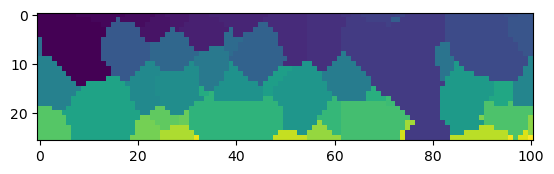

In [91]:
plt.imshow(gstslice.lgi)
plt.show()

## STEP 2 — Pixelated GS to geometric GS

`polygonised_grain_structure` parses `lgi` / grain IDs / neighbours into per-grain polygons and a GB network.

lfi - local feature id

In [95]:
geomGS = polygonised_grain_structure(gstslice.lgi, gstslice.gid, gstslice.neigh_gid)

In [98]:
geomGS.pix_to_geom(verbose=False, perform_xtal_dict_check=True)

Text(0.5, 1.0, 'raw polygons')

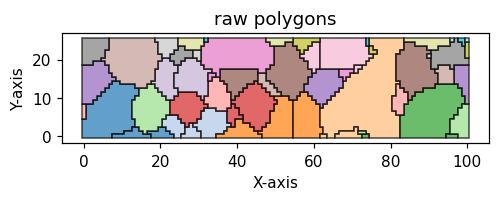

In [99]:
fig, ax = geomGS.plotgs(geomGS.POLYXTAL, figsize=(5, 5), dpi=110)
ax.set_title("raw polygons")

A grain drawn with a visible hole in this plot is a host: an island grain (counted above) is its own separate polygon exactly filling that hole, not part of the host's polygon.

## STEP 3 — Grain-boundary smoothing

Smoothing shortens stair-step pixel boundaries so Gmsh can place conformal GB edges.

In [100]:
npasses = 2
min_segment_length_factor = 2
gsname = f"gs.{npasses}passes.{min_segment_length_factor}minseglenfactor"

In [101]:
geomGS.smooth_gbsegs(
    geomGS.GB, npasses=npasses,
    max_smooth_levels=np.repeat(min_segment_length_factor, npasses),
    plot=False, name=gsname)

Assembling grain boundary segments into grain boundary multi-linestrings
Carrying out smoothing pass: 1
Carrying out smoothing pass: 2


In [102]:
pxtal = geomGS.smoothed[gsname]["POLYXTAL"]

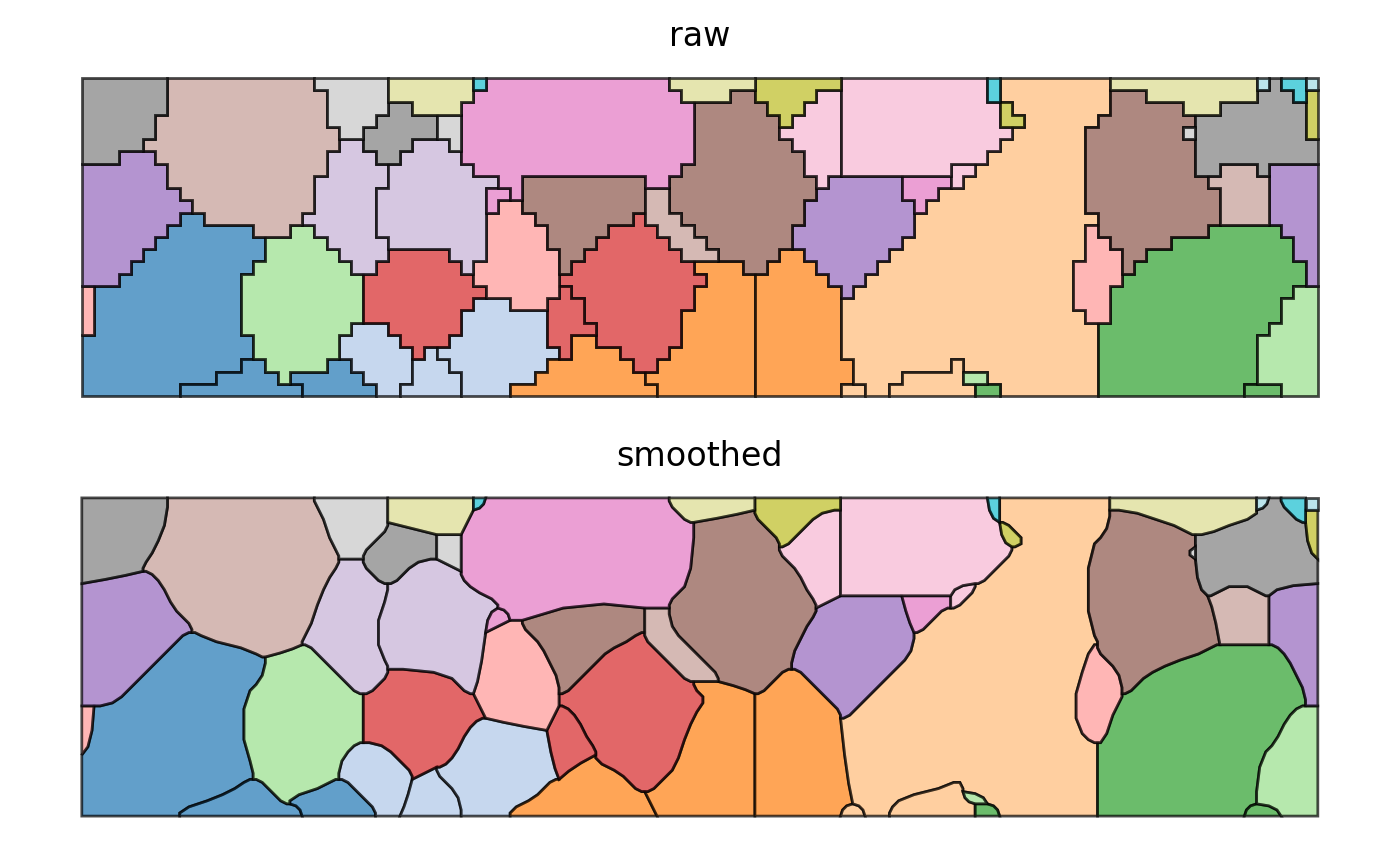

In [103]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), dpi=200)
geomGS.plotgs(geomGS.POLYXTAL, fig=fig, ax=axes[0])
axes[0].set_title("raw")
axes[0].set_axis_off()
geomGS.plotgs(pxtal, fig=fig, ax=axes[1])
axes[1].set_title("smoothed")
axes[1].set_axis_off()

## STEP 4 — Conformal FE mesh (`confMesh2dGMSH`)

`from_geometric_pxtal` builds the mesher from a geometric polycrystal. `femesh_gmsh` talks to the raw Gmsh API.

In [104]:
gsConfMesh = confMesh2dGMSH.from_geometric_pxtal(
    gsgen_method="shapely_pxtal_load",
    pxtal=pxtal,
    xbound=[gstslice.uigrid.xmin, gstslice.uigrid.xmax],
    ybound=[gstslice.uigrid.ymin, gstslice.uigrid.ymax])

In [105]:
gsConfMesh.femesh_gmsh(
    mesh_size_gb=0.5, mesh_size_bulk=1.0,
    mesh_algo=8, mesh_order=1, recombine_to_quads=False)

In [106]:
gsConfMesh.form_elsets_gmsh()

In [107]:
gsConfMesh.build_boundary_nsets()

In [108]:
gsConfMesh.build_gb_nset()

In [111]:
# gsConfMesh.validation_report

In [112]:
vr = gsConfMesh.validation_report
print(f"elements: {vr['n_tri']} tri + {vr['n_quad']} quad | "
      f"grains missing elements: {len(vr['grains_missing_elements'])} (target 0) | "
      f"inverted elements: {vr['clockwise_elements']} (target 0) | "
      f"degenerate elements: {vr['degenerate_elements']} (target 0)")

elements: 16160 tri + 0 quad | grains missing elements: 0 (target 0) | inverted elements: 0 (target 0) | degenerate elements: 0 (target 0)


Grain-coloured fill and face NSETs come from `plot_by_grain` (`upxo.viz.meshviz`). Abaqus export is `export_abaqus_inp` (`upxo.meshing.writer_ABQ`): CPS4/CPS3 for `plane='stress'`, CPE4/CPE3 for `'strain'`.

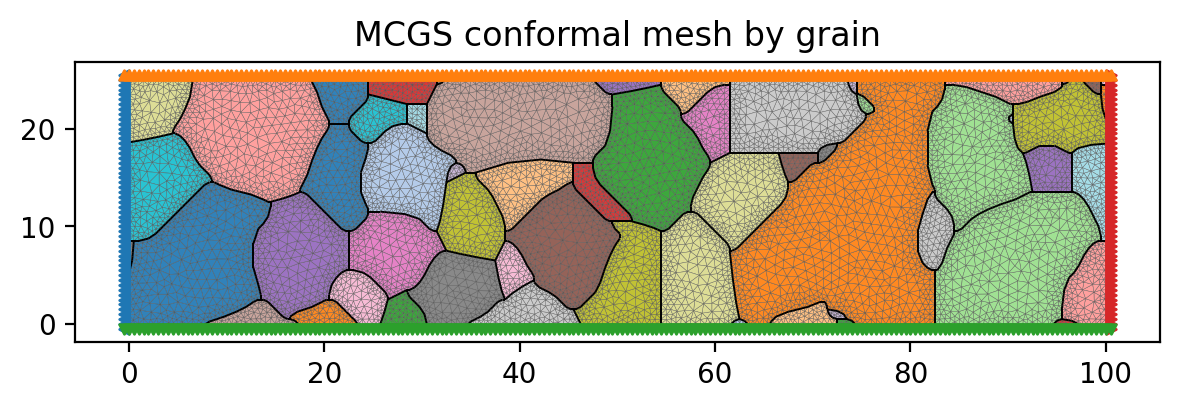

In [113]:
fig, ax = gsConfMesh.plot_by_grain(
    figsize=(6, 6), show_gb=True, show_nsets=True, dpi=200,
    title="MCGS conformal mesh by grain")
# fig

In [114]:
out = Path.cwd() / "confMesh2d_mcgs_out"
inp = gsConfMesh.export_abaqus_inp(out / "rve_cps.inp", plane="stress")
inp, summarize_inp(inp)

('c:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\confMesh\\confMesh2d_mcgs_out\\rve_cps.inp',
 {'*Node': True,
  '*Element': True,
  '*Elset': True,
  '*Nset': True,
  '*Solid Section': True,
  '*Material': True})

### UPXO Citation

Sunil Anandatheertha, Vikram Phalke, Eralp Demir, Chris Hardie, UKAEA Poly-XTAL operations (UPXO V1.0): An open-source Python package for generating, assessment and meshing of poly-crystalline grain structures, SoftwareX, Volume 34, 2026, 102736, ISSN 2352-7110, https://doi.org/10.1016/j.softx.2026.102736